In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
color = sns.color_palette()
import sklearn.metrics as metrics

import warnings
warnings.filterwarnings("ignore")

In [2]:
Default = pd.read_csv("Default.csv")
Default.head()

,Unnamed: 0,default,student,balance,income
0,1,No,No,729.526495,44361.625074
1,2,No,Yes,817.180407,12106.134700
2,3,No,No,1073.549164,31767.138947
3,4,No,No,529.250605,35704.493935
4,5,No,No,785.655883,38463.495879


In [5]:
Default.shape

(10000, 5)

In [7]:
Default.describe()

,Unnamed: 0,balance,income
count,10000.00000,10000.000000,10000.000000
mean,5000.50000,835.374886,33516.981876
std,2886.89568,483.714985,13336.639563
min,1.00000,0.000000,771.967729
25%,2500.75000,481.731105,21340.462903
50%,5000.50000,823.636973,34552.644802
75%,7500.25000,1166.308386,43807.729272
max,10000.00000,2654.322576,73554.233495


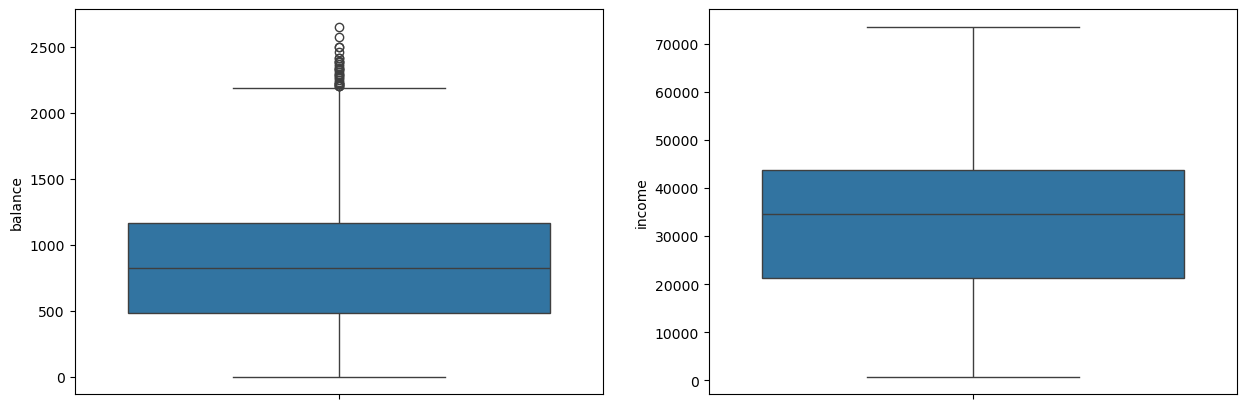

In [9]:
plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
sns.boxplot(y = Default['balance'])

plt.subplot(1,2,2)
sns.boxplot(y = Default['income'])
plt.show()


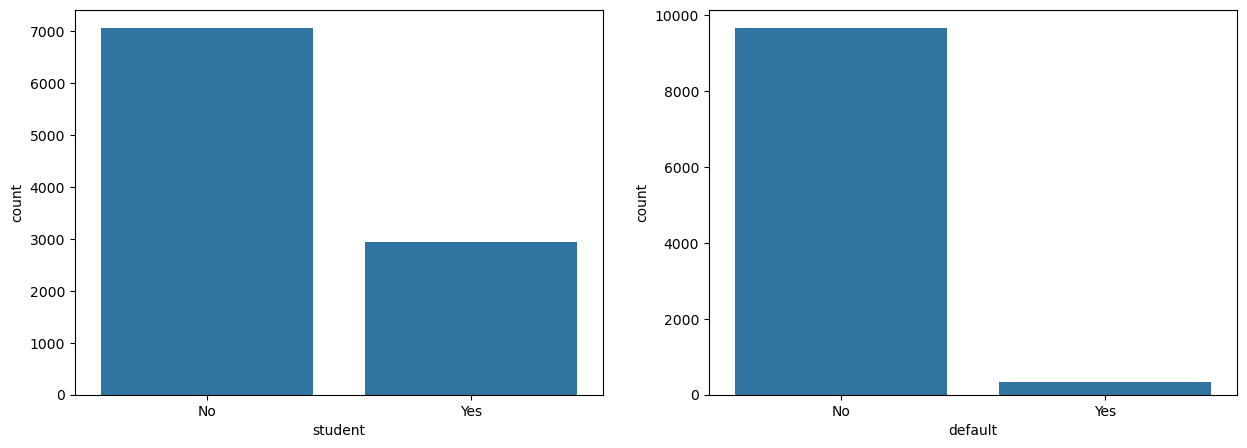

In [10]:
plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
sns.countplot(x = Default['student'])

plt.subplot(1,2,2)
sns.countplot(x = Default['default'])
plt.show()

In [12]:
Default['student'].value_counts()

student
No     7056
Yes    2944
Name: count, dtype: int64

In [14]:
Default['default'].value_counts()

default
No     9667
Yes     333
Name: count, dtype: int64

In [17]:
Default['student'].value_counts(normalize = True) 

student
No     0.7056
Yes    0.2944
Name: proportion, dtype: float64

In [19]:
Default['default'].value_counts(normalize = True)

default
No     0.9667
Yes    0.0333
Name: proportion, dtype: float64

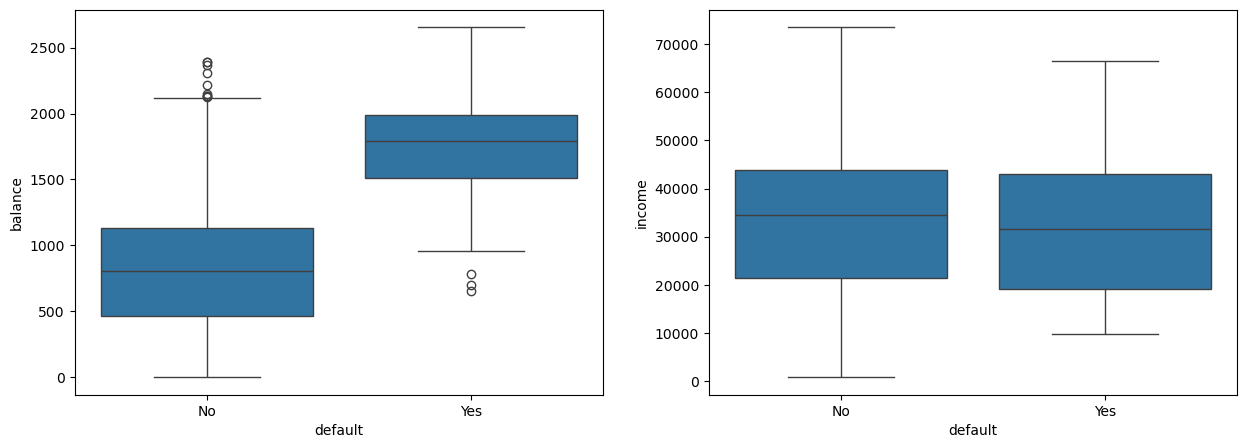

In [21]:
plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
sns.boxplot(x = Default['default'],y = Default['balance'])

plt.subplot(1,2,2)
sns.boxplot(x = Default['default'],y = Default['income'])
plt.show()

In [22]:
pd.crosstab(Default['student'],Default['default'],normalize = 'index').round(2)

default,No,Yes
student,,
No,0.97,0.03
Yes,0.96,0.04


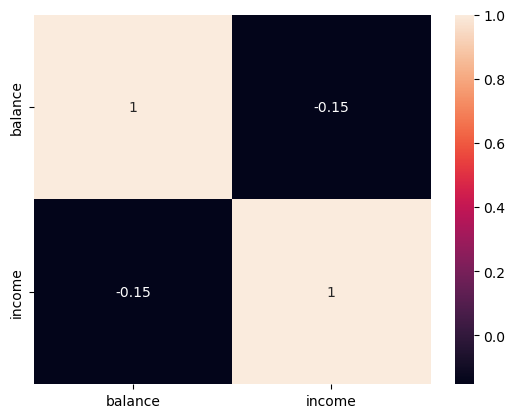

In [25]:
sns.heatmap(Default[['balance','income']].corr(),annot=True)
plt.show()

In [29]:
Default.isnull().sum()

Unnamed: 0    0
default       0
student       0
balance       0
income        0
dtype: int64

In [ ]:
#Inter Quartile range to remove outliers

In [31]:
Q1, Q3 = Default['balance'].quantile([0.25,0.75])
IQR = Q3-Q1
LL = Q1 -1.5*(IQR)
UL = Q3 + 1.5*(IQR)

In [33]:
UL

2193.1743086078154

In [35]:
df = Default[Default['balance']>UL]

In [37]:
df

,Unnamed: 0,default,student,balance,income
173,174,Yes,Yes,2205.799521,14271.492253
1136,1137,Yes,No,2499.016750,51504.293960
1160,1161,Yes,Yes,2502.684931,14947.519752
1359,1360,Yes,No,2220.966201,40725.096207
1502,1503,Yes,Yes,2332.878254,11770.234124
1609,1610,Yes,Yes,2269.946966,18021.105948
2096,2097,Yes,Yes,2261.848162,20030.165119
2140,2141,No,Yes,2308.893236,19110.266412
2929,2930,Yes,Yes,2387.314867,28296.914718
3162,3163,Yes,Yes,2415.316994,17429.503375


In [39]:
df['default'].count()

31

In [41]:
df['default'].value_counts(normalize = True)

default
Yes    0.83871
No     0.16129
Name: proportion, dtype: float64

In [43]:
df['default'].value_counts()

default
Yes    26
No      5
Name: count, dtype: int64

In [45]:
#since outliers significantly contribute to the defaulters, we can not directly remove them
#so we are here changing the balance values of these outliers as UL
Default['balance'] = np.where(Default['balance']>UL, UL, Default['balance'])


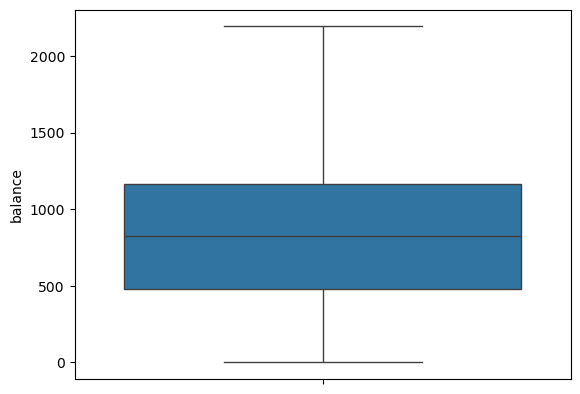

In [47]:
sns.boxplot(y=Default['balance'])
plt.show()

In [49]:
#changing categorical values(Yes/no or categories ) to numerical values so that the algorithms can be applied in better way.

In [57]:
Default = pd.get_dummies(Default, drop_first = True)

In [59]:
Default.head()

,Unnamed: 0,balance,income,default_Yes,student_Yes
0,1,729.526495,44361.625074,False,False
1,2,817.180407,12106.134700,False,True
2,3,1073.549164,31767.138947,False,False
3,4,529.250605,35704.493935,False,False
4,5,785.655883,38463.495879,False,False


In [61]:
Default.dtypes

Unnamed: 0       int64
balance        float64
income         float64
default_Yes       bool
student_Yes       bool
dtype: object

In [63]:
#boolean in python is already considered as numeric 0 False and 1 True

In [65]:
Default.columns = ['SNo','balance','income','default','student']

In [67]:
Default.head()

,SNo,balance,income,default,student
0,1,729.526495,44361.625074,False,False
1,2,817.180407,12106.134700,False,True
2,3,1073.549164,31767.138947,False,False
3,4,529.250605,35704.493935,False,False
4,5,785.655883,38463.495879,False,False


In [69]:
from sklearn.model_selection import train_test_split

In [71]:
X = Default.drop('default',axis = 1)
X = X.drop('SNo',axis = 1)
y = Default['default']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = 21,stratify = y)
#stratify divides the defaulters proportionatel as the data is highly imbalanced
# this is to avoid 0 or too many defaulters in training data

In [77]:
print(X_train.shape)
print(X_test.shape)

(7000, 3)
(3000, 3)


In [83]:
print(y_train.value_counts(normalize = True).round(2))
print(' ')
print(y_test.value_counts(normalize = True).round(2))

default
False    0.97
True     0.03
Name: proportion, dtype: float64
 
default
False    0.97
True     0.03
Name: proportion, dtype: float64


In [85]:
#SMOT = Synthetic Minority Oversampling Technique

In [89]:
from imblearn.over_sampling import SMOTE
sm =  SMOTE(random_state = 33, sampling_strategy = 0.75)
X_res, y_res = sm.fit_resample(X_train,y_train)

In [91]:
from sklearn.linear_model import LogisticRegression

In [93]:
lr = LogisticRegression()

In [95]:
lr.fit(X_res,y_res)

LogisticRegression()

In [97]:
y_pred = lr.predict(X_test)

In [99]:
from sklearn.metrics import confusion_matrix, classification_report

In [101]:
confusion_matrix(y_test,y_pred)

array([[2625,  275],
       [  17,   83]], dtype=int64)

In [103]:
#left diagonal= accurately classified values
#right diagonal = incorrectly classified values

In [105]:
(2625+83)/(2625+83+17+275)

0.9026666666666666

In [107]:
#hence we have successfully applied logistic regression algorithm to given data with 90.26%